In [18]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sys
sys.path.append("../")
from diabnet.apply_ensemble import Predictor
from diabnet.data import get_feature_names
from diabnet.ensemble import Ensemble

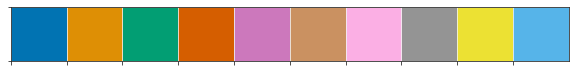

In [20]:
colors = sns.color_palette("colorblind")
sns.palplot(colors)
sns.set_style("whitegrid")
sns.set_style("ticks",{'axes.grid': True,'grid.color': '.95', 'grid.linestyle': '-'})

In [21]:
ensemble = Ensemble('../diabnet/models/model-6-soft-label-age-positives-2500-dropout0-bn-decay-flood-hyperopt-batch256-lc1-20200831')
c = get_feature_names("../datasets/visits_sp_unique_test_positivo_1000_random_0.csv", BMI=False, sex=True, parents_diagnostics=True)
pred = Predictor(ensemble, c, "../datasets/visits_sp_unique_test_positivo_1000_random_0_negatives_older60.csv")

../diabnet/models/model-6-soft-label-age-positives-2500-dropout0-bn-decay-flood-hyperopt-batch256-lc1-20200831
NEGATIVE FILE ../datasets/visits_sp_unique_test_positivo_1000_random_0_negatives_older60.csv


In [22]:
df = pd.read_csv("../datasets/visits_sp_unique_test_positivo_1000_random_0.csv")

## Qual o efeito da idade?

Grupos:
- todos os pacientes
- controle negativo (negativos >60yo)
- positivos

Valores:
- y => Pt/P(t-1)
- x => 20>t>80 

In [23]:
features = df[c].values

In [24]:
for age in range(20,85, 5):
    probs = [np.mean(pred.patient(pat_feat, age=age, samples_per_model=1)) for pat_feat in features]
    df[f"pred_age_{age}"] = probs
    

In [25]:
df

,Unnamed: 0,id,snp_8_133462953,snp_2_91635413,snp_9_25963828,snp_1_17764169,snp_12_41767967,snp_4_49530811,snp_2_96519717,snp_7_116910447,...,pred_age_35,pred_age_40,pred_age_45,pred_age_50,pred_age_55,pred_age_60,pred_age_65,pred_age_70,pred_age_75,pred_age_80
0,0,A11123,0,0,0,0,0,0,0,0,...,0.583518,0.624510,0.663972,0.701387,0.736344,0.768557,0.797864,0.824217,0.847670,0.868350
1,1,A00551,0,0,0,1,0,1,1,0,...,0.030365,0.031903,0.033559,0.035341,0.037262,0.039333,0.041566,0.043976,0.046575,0.049378
2,2,A02267,0,0,0,0,0,1,0,0,...,0.070805,0.079311,0.088903,0.099699,0.111828,0.125419,0.140608,0.157523,0.176289,0.197012
3,3,A00586,0,0,0,0,0,1,0,0,...,0.026540,0.029065,0.031909,0.035113,0.038729,0.042812,0.047425,0.052642,0.058542,0.065216
4,4,A16039,0,0,0,0,0,1,0,0,...,0.014455,0.015552,0.016769,0.018122,0.019630,0.021311,0.023190,0.025291,0.027646,0.030287
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
545,545,A02889,0,2,0,1,0,1,1,0,...,0.025530,0.026884,0.028346,0.029923,0.031626,0.033466,0.035453,0.037598,0.039913,0.042408
546,546,A26102,0,0,0,0,0,0,0,0,...,0.102042,0.116803,0.133740,0.153103,0.175132,0.200047,0.228020,0.259153,0.293449,0.330784
547,547,A03220,0,0,1,0,0,0,0,0,...,0.039594,0.043873,0.048715,0.054196,0.060400,0.067422,0.075362,0.084332,0.094451,0.105846
548,548,A39026,0,0,1,1,0,1,1,0,...,0.074162,0.078595,0.083376,0.088531,0.094086,0.100072,0.106518,0.113458,0.120923,0.128945


In [26]:
for age in range(25,85, 5):
    df[f"pred_diff_ages_{age}-{age-5}"] = df[f"pred_age_{age}"] - df[f"pred_age_{age-5}"]

In [27]:
df2 = df.filter(regex='pred_diff')

In [28]:
df3 = df.filter(regex='pred_diff').describe().transpose()
df4 = df[df.T2D == 1].filter(regex='pred_diff').describe().transpose()
df5 = df[(df.T2D == 0) & (df.AGE > 60)].filter(regex='pred_diff').describe().transpose()

In [29]:
df2

,pred_diff_ages_25-20,pred_diff_ages_30-25,pred_diff_ages_35-30,pred_diff_ages_40-35,pred_diff_ages_45-40,pred_diff_ages_50-45,pred_diff_ages_55-50,pred_diff_ages_60-55,pred_diff_ages_65-60,pred_diff_ages_70-65,pred_diff_ages_75-70,pred_diff_ages_80-75
0,0.041833,0.042205,0.041922,0.040992,0.039462,0.037414,0.034957,0.032213,0.029307,0.026354,0.023452,0.020680
1,0.001242,0.001333,0.001432,0.001539,0.001655,0.001783,0.001921,0.002071,0.002233,0.002409,0.002599,0.002803
2,0.005895,0.006667,0.007535,0.008507,0.009591,0.010796,0.012128,0.013592,0.015188,0.016916,0.018765,0.020723
3,0.001784,0.002000,0.002246,0.002526,0.002843,0.003205,0.003616,0.004083,0.004614,0.005216,0.005900,0.006674
4,0.000808,0.000893,0.000989,0.001096,0.001217,0.001353,0.001507,0.001682,0.001879,0.002102,0.002355,0.002641
...,...,...,...,...,...,...,...,...,...,...,...,...
545,0.001083,0.001166,0.001256,0.001355,0.001461,0.001577,0.001703,0.001840,0.001987,0.002145,0.002315,0.002495
546,0.009639,0.011127,0.012828,0.014761,0.016937,0.019363,0.022030,0.024915,0.027973,0.031133,0.034296,0.037335
547,0.002970,0.003351,0.003785,0.004279,0.004842,0.005481,0.006204,0.007021,0.007940,0.008970,0.010119,0.011395
548,0.003538,0.003813,0.004111,0.004434,0.004781,0.005154,0.005555,0.005986,0.006447,0.006940,0.007465,0.008022


<AxesSubplot:ylabel='mean'>

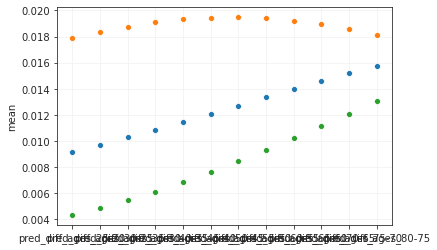

In [30]:
sns.scatterplot(y='mean', x=df3.index, data=df3)
sns.scatterplot(y='mean', x=df4.index, data=df4)
sns.scatterplot(y='mean', x=df5.index, data=df5)

<AxesSubplot:>

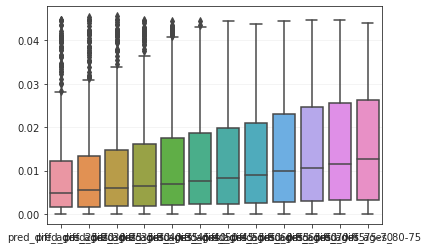

In [31]:
sns.boxplot(data=df2)

<AxesSubplot:>

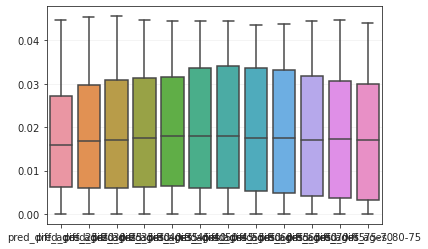

In [32]:
sns.boxplot(data=df[df.T2D == 1].filter(regex='pred_diff'))

<AxesSubplot:>

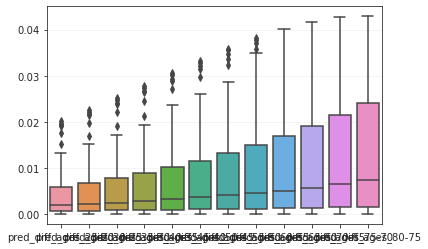

In [33]:
sns.boxplot(data=df[(df.T2D == 0) & (df.AGE > 60)].filter(regex='pred_diff'))